# TabICL Embedding Visualization with t-SNE

This notebook demonstrates the three new embedding outputs added to `TabICLClassifier.predict_proba`:

| Flag | What it returns | Shape |
|------|----------------|-------|
| `return_col_embedding_sample` | Per-column embedding from the first ensemble member | `(n_features, embed_dim)` |
| `return_test_representations` | Test-row representations after the row-interaction stage | `(n_estimators, n_test, d_row)` |
| `return_test_icl_representations` | Test-row representations just before the ICL decoder (post-LayerNorm) | `(n_estimators, n_test, d_icl)` |

We use the two-moon dataset from the probabilistic-classification tutorial and t-SNE to project each embedding type down to 2D.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_moons
from sklearn.manifold import TSNE
from tabicl import TabICLClassifier

/Users/wangc/projects/Embedding/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Dataset

In [2]:
X, y = make_moons(n_samples=1000, noise=0.35, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (800, 2), Test: (200, 2)


## 2. Fit TabICL

We pass the local checkpoint path to avoid downloading from HuggingFace Hub.

In [3]:
MODEL_PATH = "/Users/wangc/projects/ai-ml-models/TabICL/tabicl-classifier-v2-20260212.ckpt"

tabicl = TabICLClassifier(model_path=MODEL_PATH)
tabicl.fit(X_train, y_train)

,n_estimators,8
,norm_methods,None
,feat_shuffle_method,'latin'
,class_shuffle_method,'shift'
,outlier_threshold,4.0
,softmax_temperature,0.9
,average_logits,True
,support_many_classes,True
,batch_size,8
,kv_cache,False
,model_path,'/Users/wangc/projects/...sifier-v2-20260212.ckpt'


## 3. Retrieve all three embedding types in a single forward pass

In [4]:
result = tabicl.predict_proba(
    X_test,
    return_col_embedding_sample=True,
    return_test_representations=True,
    return_test_icl_representations=True,
)
proba, col_embedding_sample, test_representations, test_icl_representations = result

print("proba shape              :", proba.shape)
print("col_embedding_sample shape:", col_embedding_sample.shape)
print("test_representations shape:", test_representations.shape)
print("test_icl_representations  :", test_icl_representations.shape)

proba shape              : (200, 2)
col_embedding_sample shape: (6, 128)
test_representations shape: (8, 200, 512)
test_icl_representations  : (8, 200, 512)


## 4. t-SNE of column embeddings

`col_embedding_sample` has shape `(n_features, embed_dim)`.  Each point is one feature column.
With only 2 features in the two-moon dataset the t-SNE degenerates to 2 points — we use it here to show the API; on a real dataset with many features the clustering is more meaningful.

n_features=6, embedding dim=128


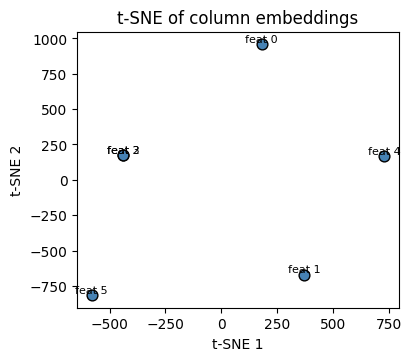

In [5]:
n_features = col_embedding_sample.shape[0]
print(f"n_features={n_features}, embedding dim={col_embedding_sample.shape[1]}")

# t-SNE makes sense only with ≥2 samples; with 2 features we skip it and just show raw coordinates.
if n_features >= 3:
    perplexity = min(30, n_features - 1)
    tsne_col = TSNE(n_components=2, perplexity=perplexity, random_state=0)
    col_2d = tsne_col.fit_transform(col_embedding_sample)
    fig, ax = plt.subplots(figsize=(4, 3.5), constrained_layout=True)
    ax.scatter(col_2d[:, 0], col_2d[:, 1], s=60, c="steelblue", edgecolors="k")
    for i in range(n_features):
        ax.annotate(f"feat {i}", col_2d[i], fontsize=8, ha="center", va="bottom")
    ax.set(title="t-SNE of column embeddings", xlabel="t-SNE 1", ylabel="t-SNE 2")
    plt.show()
else:
    # Raw 2-D embedding coordinates
    print("Only 2 features — raw embedding coordinates (no t-SNE):")
    for i, emb in enumerate(col_embedding_sample):
        print(f"  feature {i}: mean={emb.mean():.4f}, std={emb.std():.4f}, norm={np.linalg.norm(emb):.4f}")

## 5. t-SNE of test row representations (row-interaction stage)

`test_representations` has shape `(n_estimators, n_test, d_row)`.
We average across the ensemble dimension (axis 0) before projecting.

test_representations raw shape : (8, 200, 512)
row_repr after ensemble-mean   : (200, 512)


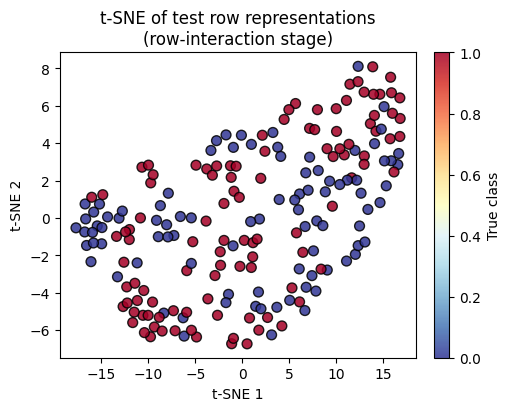

In [6]:
# Average across ensemble dimension (axis 0) -> (n_test, d_row)
row_repr = test_representations.mean(axis=0) if test_representations.ndim == 3 else test_representations
print(f"test_representations raw shape : {test_representations.shape}")
print(f"row_repr after ensemble-mean   : {row_repr.shape}")

perplexity = min(30, len(y_test) - 1)
tsne_row = TSNE(n_components=2, perplexity=perplexity, random_state=0)
row_2d = tsne_row.fit_transform(row_repr)

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
scatter = ax.scatter(
    row_2d[:, 0], row_2d[:, 1],
    c=y_test, cmap="RdYlBu_r",
    edgecolors="k", s=50, alpha=0.85,
)
plt.colorbar(scatter, ax=ax, label="True class")
ax.set(title="t-SNE of test row representations\n(row-interaction stage)",
       xlabel="t-SNE 1", ylabel="t-SNE 2")
plt.show()

## 6. t-SNE of test ICL representations (pre-decoder stage)

`test_icl_representations` has shape `(n_estimators, n_test, d_icl)` — these are the post-LayerNorm activations just before the classification decoder.
We average across the ensemble dimension (axis 0) before projecting.

test_icl_representations raw shape: (8, 200, 512)
icl_repr after ensemble-mean      : (200, 512)


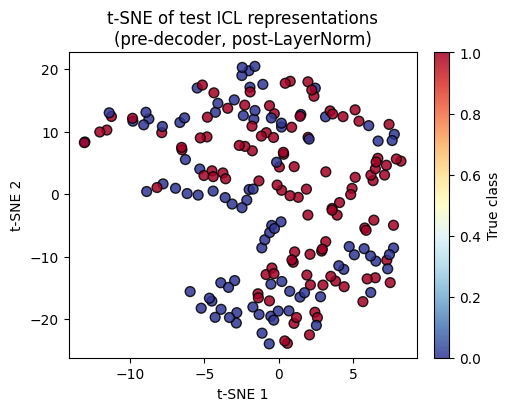

In [7]:
# Average across ensemble dimension (axis 0) -> (n_test, d_icl)
icl_repr = test_icl_representations.mean(axis=0) if test_icl_representations.ndim == 3 else test_icl_representations
print(f"test_icl_representations raw shape: {test_icl_representations.shape}")
print(f"icl_repr after ensemble-mean      : {icl_repr.shape}")

perplexity = min(30, len(y_test) - 1)
tsne_icl = TSNE(n_components=2, perplexity=perplexity, random_state=0)
icl_2d = tsne_icl.fit_transform(icl_repr)

fig, ax = plt.subplots(figsize=(5, 4), constrained_layout=True)
scatter = ax.scatter(
    icl_2d[:, 0], icl_2d[:, 1],
    c=y_test, cmap="RdYlBu_r",
    edgecolors="k", s=50, alpha=0.85,
)
plt.colorbar(scatter, ax=ax, label="True class")
ax.set(title="t-SNE of test ICL representations\n(pre-decoder, post-LayerNorm)",
       xlabel="t-SNE 1", ylabel="t-SNE 2")
plt.show()

## 7. Side-by-side comparison

We compare both representation types side by side, coloured by the **predicted** class confidence.

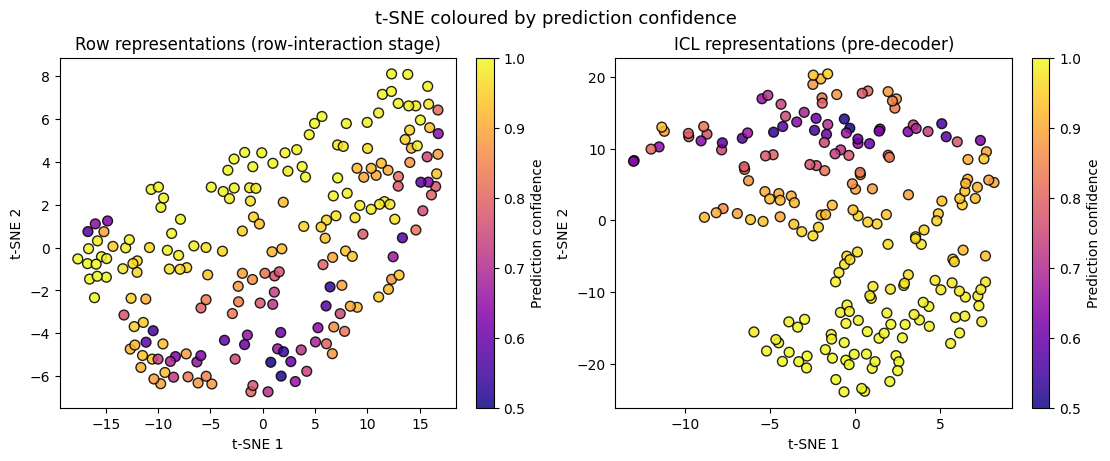

In [8]:
confidence = proba.max(axis=1)  # highest class probability per sample

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), constrained_layout=True)

for ax, coords, title in [
    (axes[0], row_2d,  "Row representations (row-interaction stage)"),
    (axes[1], icl_2d,  "ICL representations (pre-decoder)"),
]:
    sc = ax.scatter(
        coords[:, 0], coords[:, 1],
        c=confidence, cmap="plasma",
        edgecolors="k", s=50, alpha=0.85, vmin=0.5, vmax=1.0,
    )
    plt.colorbar(sc, ax=ax, label="Prediction confidence")
    ax.set(title=title, xlabel="t-SNE 1", ylabel="t-SNE 2")

fig.suptitle("t-SNE coloured by prediction confidence", fontsize=13)
plt.show()

## 8. Instance attributes after predict_proba

As a convenience, `predict_proba` also stores all requested embeddings as fitted attributes on the estimator object so you can access them without unpacking the return value.

In [9]:
print("tabicl.col_embedding_sample_ shape  :", tabicl.col_embedding_sample_.shape)
print("tabicl.test_representations_ shape  :", tabicl.test_representations_.shape)
print("tabicl.test_icl_representations_ shape:", tabicl.test_icl_representations_.shape)

tabicl.col_embedding_sample_ shape  : (6, 128)
tabicl.test_representations_ shape  : (8, 200, 512)
tabicl.test_icl_representations_ shape: (8, 200, 512)
